
# Multilevel dispersive theory for an electron on helium in a tilted magnetic field



1. solve the vertical Hamiltonian $H_z$ for an electron above helium,
2. construct the multilevel coupling matrix $g_{nm}=\gamma_B z_{nm}$,
3. compare the multilevel second-order dispersive theory with a truncated exact diagonalization of the full Hamiltonian,
4. map the parameter regions where the language *two-subband dispersive*, *multilevel dispersive*, *quasi-dispersive*, and *near-resonant / hybridized* is appropriate.

The notebook uses the notation adopted for the manuscript draft:
$
H = \sum_n \epsilon_n |n\rangle\langle n| + \hbar \omega_c \left(a^\dagger a + \frac12\right)
+ \hbar \sum_{n,m} g_{nm} |n\rangle\langle m| (a+a^\dagger),
\qquad
g_{nm} = \frac{\omega_y}{\sqrt{2}l_B} z_{nm}.
$

All frequencies inside the code are stored in angular-frequency units when needed and converted to GHz or MHz for plots.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass
from functools import lru_cache

from scipy.constants import e, h, hbar, m_e, epsilon_0
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh
from scipy.linalg import eigh

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": False,
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
})

TWOPI = 2 * np.pi
GHz = TWOPI * 1e9
MHz = TWOPI * 1e6

import pathlib

## 1. Constants, units, and helper functions

We use the standard image-potential model for electrons on liquid $^4$He.  
The numerical solver below works in the natural units of the image-potential problem:

- length unit: $r_B = \hbar^2/(m_e \Lambda_{\rm im})$,
- energy unit: $R = m_e \Lambda_{\rm im}^2/(2\hbar^2)$.

With this choice, the dimensionless vertical Hamiltonian reads
$
\frac{H_z}{R} = -\frac{d^2}{du^2} - \frac{2}{u} + c_E u + \frac{c_B}{2}u^2,
\qquad
u = z/r_B.
$

In [3]:
EPS_HE4 = 1.0572

def image_potential_constant(eps_r=EPS_HE4):
    return (eps_r - 1.0) / (eps_r + 1.0) * e**2 / (16.0 * np.pi * epsilon_0)

LAMBDA_IM = image_potential_constant(EPS_HE4)
R_EFF = m_e * LAMBDA_IM**2 / (2.0 * hbar**2)          # Joule
RB_EFF = hbar**2 / (m_e * LAMBDA_IM)                  # meter

print(f"Effective Bohr radius r_B = {RB_EFF*1e9:.3f} nm")
print(f"Effective Rydberg R/h = {R_EFF/h/1e9:.3f} GHz")

Effective Bohr radius r_B = 7.613 nm
Effective Rydberg R/h = 158.962 GHz


In [4]:
@dataclass(frozen=True)
class VerticalConfig:
    E_perp_V_per_cm: float = 30.0
    u_max: float = 120.0
    n_grid: int = 1600
    n_states: int = 8
    eps_r: float = EPS_HE4

def cyclotron_frequency(Bz_T):
    return e * Bz_T / m_e

def inplane_frequency(By_T):
    return e * By_T / m_e

def magnetic_length(Bz_T):
    return np.sqrt(hbar / (e * Bz_T))

def coupling_prefactor(By_T, Bz_T):
    return inplane_frequency(By_T) / (np.sqrt(2.0) * magnetic_length(Bz_T))

def landau_ops(n_landau):
    a = np.zeros((n_landau, n_landau))
    for n in range(1, n_landau):
        a[n-1, n] = np.sqrt(n)
    adag = a.T
    num = adag @ a
    x = a + adag
    return a, adag, num, x

def _vertical_key(By_T, cfg):
    return (
        round(float(By_T), 10),
        round(float(cfg.E_perp_V_per_cm), 10),
        round(float(cfg.u_max), 10),
        int(cfg.n_grid),
        int(cfg.n_states),
        round(float(cfg.eps_r), 10),
    )

_VERTICAL_CACHE = {}

def solve_vertical(By_T, cfg=VerticalConfig()):
    key = _vertical_key(By_T, cfg)
    if key in _VERTICAL_CACHE:
        return _VERTICAL_CACHE[key]

    omega_y = inplane_frequency(By_T)
    E_perp = cfg.E_perp_V_per_cm * 100.0

    du = cfg.u_max / (cfg.n_grid + 1)
    u = du * (np.arange(cfg.n_grid) + 1)

    lap = diags(
        [np.ones(cfg.n_grid-1), -2*np.ones(cfg.n_grid), np.ones(cfg.n_grid-1)],
        offsets=[-1, 0, 1],
        format="csc",
    ) / du**2

    cE = e * E_perp * RB_EFF / R_EFF
    cB = m_e * omega_y**2 * RB_EFF**2 / R_EFF

    V = -2.0 / u + cE * u + 0.5 * cB * u**2
    H = -lap + diags(V, 0, format="csc")

    vals, vecs = eigsh(H, k=cfg.n_states, which="SA", tol=1e-9, maxiter=500000)
    order = np.argsort(vals)
    vals = vals[order]
    vecs = vecs[:, order]

    for i in range(vecs.shape[1]):
        if vecs[np.argmax(np.abs(vecs[:, i])), i] < 0:
            vecs[:, i] *= -1
        vecs[:, i] /= np.sqrt(np.sum(np.abs(vecs[:, i])**2) * du)

    umat = vecs.T @ (u[:, None] * vecs) * du
    zmat = RB_EFF * umat
    energies = vals * R_EFF
    z_grid = u * RB_EFF

    result = {
        "u": u,
        "z_m": z_grid,
        "energies_J": energies,
        "eigvecs": vecs,
        "umat": umat,
        "zmat_m": zmat,
    }
    _VERTICAL_CACHE[key] = result
    return result

def multilevel_shift(energies_J, zmat_m, Bz_T, By_T, m_index, n_use=None):
    omega = energies_J / hbar
    omega_c = cyclotron_frequency(Bz_T)
    gamma_B = coupling_prefactor(By_T, Bz_T)

    N = len(omega) if n_use is None else min(len(omega), n_use)
    zloc = zmat_m[:N, :N]
    shift = 0.0
    for n in range(N):
        if n == m_index:
            continue
        omega_nm = omega[n] - omega[m_index]
        g_nm = gamma_B * zloc[n, m_index]
        shift += -2.0 * abs(g_nm)**2 * omega_nm / (omega_nm**2 - omega_c**2)
    return shift

def two_subband_shifts(energies_J, zmat_m, Bz_T, By_T):
    omega = energies_J / hbar
    omega_c = cyclotron_frequency(Bz_T)
    gamma_B = coupling_prefactor(By_T, Bz_T)

    omega_q = omega[1] - omega[0]
    g12 = gamma_B * zmat_m[0, 1]
    shift = 2.0 * abs(g12)**2 * omega_q / (omega_q**2 - omega_c**2)
    return {
        "delta_ground": -shift,
        "delta_excited": +shift,
        "g12": abs(g12),
        "omega_q": omega_q,
        "omega_c": omega_c,
    }

def eta_max(energies_J, zmat_m, Bz_T, By_T, n_use=None, m_targets=(0, 1)):
    omega = energies_J / hbar
    omega_c = cyclotron_frequency(Bz_T)
    gamma_B = coupling_prefactor(By_T, Bz_T)

    N = len(omega) if n_use is None else min(len(omega), n_use)
    zloc = zmat_m[:N, :N]

    values = []
    for m in m_targets:
        for n in range(N):
            if n == m:
                continue
            omega_nm = omega[n] - omega[m]
            g_nm = abs(gamma_B * zloc[n, m])
            values.append(g_nm / abs(omega_nm - omega_c))
            values.append(g_nm / abs(omega_nm + omega_c))
    return float(np.max(values))

def exact_branch_frequencies(energies_J, zmat_m, Bz_T, By_T, n_sub=8, n_landau=12):
    omega = energies_J[:n_sub] / hbar
    Z = zmat_m[:n_sub, :n_sub]
    omega_c = cyclotron_frequency(Bz_T)
    gamma_B = coupling_prefactor(By_T, Bz_T)

    _, _, num, x = landau_ops(n_landau)
    I_sub = np.eye(n_sub)
    I_land = np.eye(n_landau)

    H = (
        np.kron(np.diag(omega), I_land)
        + np.kron(I_sub, omega_c * (num + 0.5 * np.eye(n_landau)))
        + np.kron(gamma_B * Z, x)
    )

    evals, evecs = eigh(H)

    basis = {}
    dim = n_sub * n_landau
    for m in (0, 1):
        for ell in (0, 1):
            vec = np.zeros(dim)
            vec[m * n_landau + ell] = 1.0
            basis[(m, ell)] = vec

    overlaps = {key: np.abs(evecs.T @ vec)**2 for key, vec in basis.items()}
    assigned = {}
    used = set()

    for key in basis:
        order = np.argsort(overlaps[key])[::-1]
        for idx in order:
            if idx not in used:
                assigned[key] = evals[idx]
                used.add(idx)
                break

    return {
        0: assigned[(0, 1)] - assigned[(0, 0)],
        1: assigned[(1, 1)] - assigned[(1, 0)],
    }

def frequency_GHz(omega_rad_s):
    return omega_rad_s / GHz

def shift_MHz(omega_rad_s):
    return omega_rad_s / MHz

## 2. Default numerical parameters

These are just notebook defaults.
For the figures, the most important control knobs are

- $E_\perp$: holding field,
- $B_z$: cyclotron frequency,
- $B_y$: tilt-controlled coupling.

The figures below use $E_\perp=30$ V/cm unless stated otherwise, because this is a convenient point where the multilevel character of the excited branch is very clear.

In [5]:
cfg = VerticalConfig(
    E_perp_V_per_cm=30.0,
    u_max=120.0,
    n_grid=1600,
    n_states=8,
)

Bz_demo = 0.65
By_demo = 0.30
n_sub_exact = 8
n_landau_exact = 12

## 3. Vertical subbands and matrix elements

We first solve $H_z$ at fixed $B_y$.  
This gives the subband energies $\epsilon_n$ and the coordinate matrix elements $z_{nm}$, which are the only ingredients needed for the multilevel dispersive shifts.

In [6]:
sol0 = solve_vertical(0.0, cfg)
z_nm = sol0["z_m"] * 1e9
energies0 = sol0["energies_J"]

rydberg_freqs = (energies0 - energies0[0]) / h / 1e9
print("First five subband frequencies relative to the ground state (GHz):")
for i in range(5):
    print(f"  n={i+1}: {rydberg_freqs[i]:8.3f} GHz")

print()
print(f"Transition nu_21 at B_y=0: {rydberg_freqs[1]:.3f} GHz")
print(f"z_11 = {sol0['zmat_m'][0,0]*1e9:.3f} nm")
print(f"z_22 = {sol0['zmat_m'][1,1]*1e9:.3f} nm")
print(f"z_12 = {sol0['zmat_m'][0,1]*1e9:.3f} nm")

First five subband frequencies relative to the ground state (GHz):
  n=1:    0.000 GHz
  n=2:  140.184 GHz
  n=3:  187.360 GHz
  n=4:  219.114 GHz
  n=5:  244.873 GHz

Transition nu_21 at B_y=0: 140.184 GHz
z_11 = 11.072 nm
z_22 = 36.937 nm
z_12 = 4.626 nm


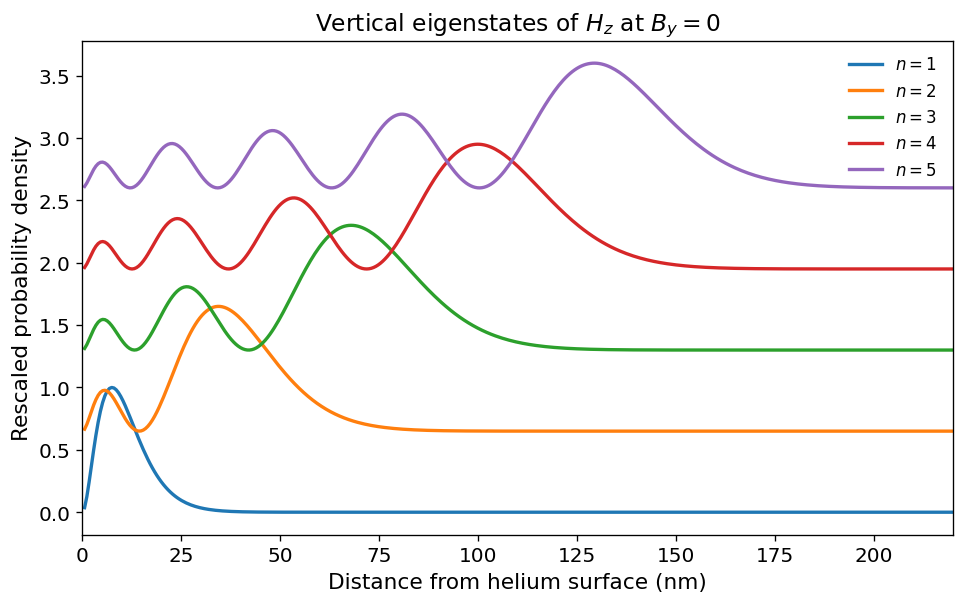

In [7]:
fig, ax = plt.subplots(figsize=(8.2, 5.2))
for i in range(5):
    density = sol0["eigvecs"][:, i]**2
    density = density / density.max()
    ax.plot(z_nm, density + i * 0.65, lw=2, label=fr"$n={i+1}$")
ax.set_xlim(0, 220)
ax.set_xlabel("Distance from helium surface (nm)")
ax.set_ylabel("Rescaled probability density")
ax.set_title(r"Vertical eigenstates of $H_z$ at $B_y=0$")
ax.legend(ncol=1, frameon=False, loc="upper right")
plt.tight_layout()
plt.show()

## 4. One operating point: numbers at $B_z=0.65$ T and $B_y=0.30$ T

This is a useful sanity check before sweeping parameters.

In [8]:
sold = solve_vertical(By_demo, cfg)
E = sold["energies_J"]
Z = sold["zmat_m"]

ml_ground = multilevel_shift(E, Z, Bz_demo, By_demo, m_index=0, n_use=cfg.n_states)
ml_excited = multilevel_shift(E, Z, Bz_demo, By_demo, m_index=1, n_use=cfg.n_states)
two = two_subband_shifts(E, Z, Bz_demo, By_demo)
exact = exact_branch_frequencies(E, Z, Bz_demo, By_demo, n_sub=n_sub_exact, n_landau=n_landau_exact)

omega_c = cyclotron_frequency(Bz_demo)

print(f"nu_c                = {frequency_GHz(omega_c):.3f} GHz")
print(f"nu_21               = {frequency_GHz((E[1]-E[0])/hbar):.3f} GHz")
print(f"g_12/2pi            = {frequency_GHz(two['g12']):.3f} GHz")
print(f"eta_max             = {eta_max(E, Z, Bz_demo, By_demo, n_use=cfg.n_states):.4f}")
print()
print("Cyclotron branch shifts relative to the bare cyclotron frequency:")
print(f"  exact,    m=1     = {shift_MHz(exact[0] - omega_c):8.3f} MHz")
print(f"  exact,    m=2     = {shift_MHz(exact[1] - omega_c):8.3f} MHz")
print(f"  multilevel, m=1   = {shift_MHz(ml_ground):8.3f} MHz")
print(f"  multilevel, m=2   = {shift_MHz(ml_excited):8.3f} MHz")
print(f"  two-subband, m=1  = {shift_MHz(two['delta_ground']):8.3f} MHz")
print(f"  two-subband, m=2  = {shift_MHz(two['delta_excited']):8.3f} MHz")
print()
print(f"Multilevel splitting   = {shift_MHz(abs(ml_excited - ml_ground)):.3f} MHz")
print(f"Two-subband splitting  = {shift_MHz(abs(two['delta_excited'] - two['delta_ground'])):.3f} MHz")

nu_c                = 18.195 GHz
nu_21               = 142.808 GHz
g_12/2pi            = 0.874 GHz
eta_max             = 0.0656

Cyclotron branch shifts relative to the bare cyclotron frequency:
  exact,    m=1     =  -15.115 MHz
  exact,    m=2     = -269.360 MHz
  multilevel, m=1   =  -14.899 MHz
  multilevel, m=2   = -228.761 MHz
  two-subband, m=1  =  -10.879 MHz
  two-subband, m=2  =   10.879 MHz

Multilevel splitting   = 213.862 MHz
Two-subband splitting  = 21.759 MHz


## 5. Fixed-$B_z$ sweep: exact diagonalization vs multilevel dispersive theory vs two-subband estimate

This figure is the most direct test of the new narrative.

- The ground-state branch is close to the two-subband estimate at small and moderate tilt.
- The first-excited branch is not.
- The multilevel second-order theory tracks the exact diagonalization much better than the two-subband model and shows where the second-order description starts to bend away at larger tilt.

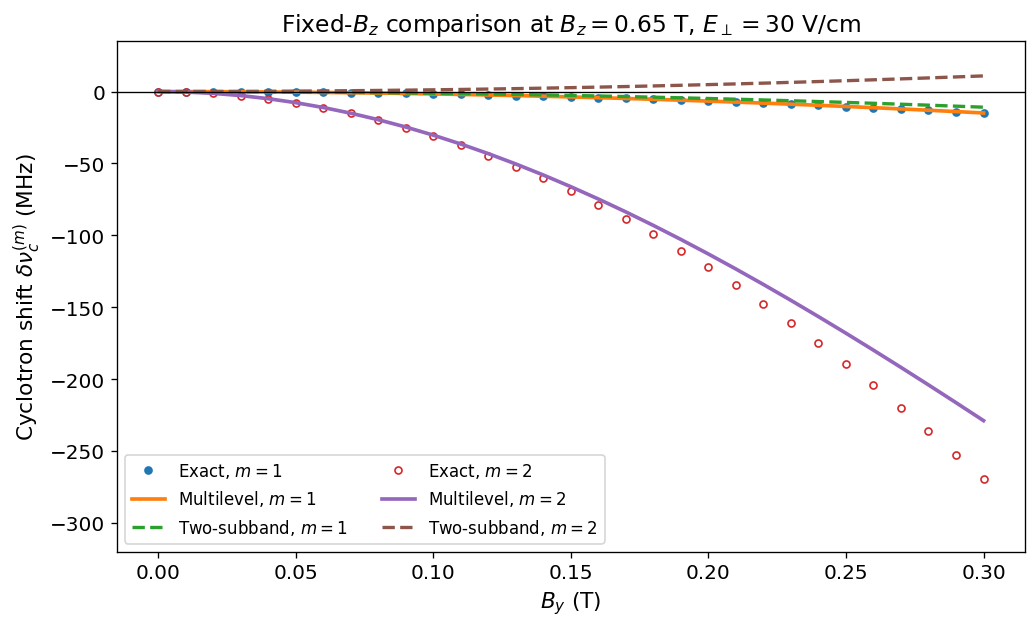

Saved: C:\notebooks\new_EonHe\ehe_theory_figures\fixed_Bz_comparison.png
Max eta_max in this sweep: 0.0656


In [11]:
def sweep_fixed_Bz(By_values, Bz_T, cfg, n_sub_exact=8, n_landau_exact=12):
    rows = []
    omega_c = cyclotron_frequency(Bz_T)
    for By in By_values:
        sol = solve_vertical(By, cfg)
        E = sol["energies_J"]
        Z = sol["zmat_m"]

        ml1 = multilevel_shift(E, Z, Bz_T, By, 0, n_use=cfg.n_states)
        ml2 = multilevel_shift(E, Z, Bz_T, By, 1, n_use=cfg.n_states)
        two = two_subband_shifts(E, Z, Bz_T, By)
        ex = exact_branch_frequencies(E, Z, Bz_T, By, n_sub=n_sub_exact, n_landau=n_landau_exact)

        rows.append({
            "By": By,
            "exact_m1_MHz": shift_MHz(ex[0] - omega_c),
            "exact_m2_MHz": shift_MHz(ex[1] - omega_c),
            "multi_m1_MHz": shift_MHz(ml1),
            "multi_m2_MHz": shift_MHz(ml2),
            "two_m1_MHz": shift_MHz(two["delta_ground"]),
            "two_m2_MHz": shift_MHz(two["delta_excited"]),
            "eta_max": eta_max(E, Z, Bz_T, By, n_use=cfg.n_states),
        })
    return rows

By_values = np.linspace(0.0, 0.30, 31)
rows = sweep_fixed_Bz(By_values, Bz_demo, cfg, n_sub_exact=n_sub_exact, n_landau_exact=n_landau_exact)

By_arr = np.array([r["By"] for r in rows])
exact_m1 = np.array([r["exact_m1_MHz"] for r in rows])
exact_m2 = np.array([r["exact_m2_MHz"] for r in rows])
multi_m1 = np.array([r["multi_m1_MHz"] for r in rows])
multi_m2 = np.array([r["multi_m2_MHz"] for r in rows])
two_m1 = np.array([r["two_m1_MHz"] for r in rows])
two_m2 = np.array([r["two_m2_MHz"] for r in rows])
eta_arr = np.array([r["eta_max"] for r in rows])

fig, ax = plt.subplots(figsize=(8.8, 5.4))
ax.plot(By_arr, exact_m1, "o", ms=4.2, label="Exact, $m=1$")
ax.plot(By_arr, multi_m1, "-", lw=2.2, label="Multilevel, $m=1$")
ax.plot(By_arr, two_m1, "--", lw=2.0, label="Two-subband, $m=1$")

ax.plot(By_arr, exact_m2, "o", ms=4.2, mfc="white", label="Exact, $m=2$")
ax.plot(By_arr, multi_m2, "-", lw=2.2, label="Multilevel, $m=2$")
ax.plot(By_arr, two_m2, "--", lw=2.0, label="Two-subband, $m=2$")

ax.axhline(0.0, color="black", lw=0.8)
ax.set_xlabel(r"$B_y$ (T)")
ax.set_ylabel(r"Cyclotron shift $\delta \nu_c^{(m)}$ (MHz)")
ax.set_title(rf"Fixed-$B_z$ comparison at $B_z={Bz_demo:.2f}$ T, $E_\perp={cfg.E_perp_V_per_cm:.0f}$ V/cm")
ax.set_ylim(-320, 35)
ax.legend(ncol=2, frameon=True, loc="lower left")
plt.tight_layout()

figure_dir = pathlib.Path.cwd() / "ehe_theory_figures"
figure_dir.mkdir(parents=True, exist_ok=True)
fixed_bz_path = figure_dir / "fixed_Bz_comparison.png"
plt.savefig(fixed_bz_path, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved: {fixed_bz_path}")
print(f"Max eta_max in this sweep: {eta_arr.max():.4f}")

## 6. Experiment-focused map: where the splitting is large in the 5--20 GHz cyclotron window

In the experimentally friendly microwave window one mostly cares about two questions:

1. Is the theory still safely dispersive?
2. Is the state-dependent cyclotron splitting big enough to resolve?

The map below answers the second question directly by showing the multilevel prediction
$
|\delta \nu_c^{(2)} - \delta \nu_c^{(1)}|.
$
In the same window, $\eta_{\max}$ stays small, so the second-order language remains controlled.  
The important message is that in this window the splitting is already appreciable, but it is intrinsically multilevel almost everywhere.

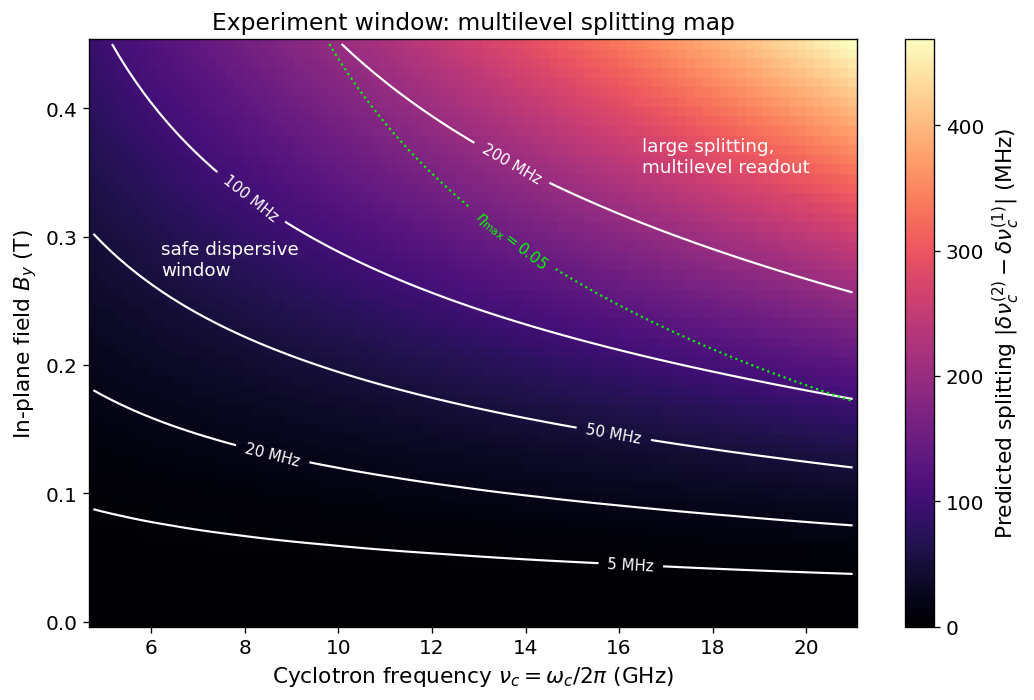

Saved: C:\notebooks\new_EonHe\ehe_theory_figures\experiment_window_split_map.png
Max eta_max in the whole 5-20 GHz window: 0.0953


In [15]:
def experiment_window_map(cfg, By_values, Bz_values):
    split = np.zeros((len(By_values), len(Bz_values)))
    eta = np.zeros_like(split)

    for i, By in enumerate(By_values):
        sol = solve_vertical(By, cfg)
        E = sol["energies_J"]
        Z = sol["zmat_m"]

        for j, Bz in enumerate(Bz_values):
            d1 = multilevel_shift(E, Z, Bz, By, 0, n_use=cfg.n_states)
            d2 = multilevel_shift(E, Z, Bz, By, 1, n_use=cfg.n_states)
            split[i, j] = shift_MHz(abs(d2 - d1))
            eta[i, j] = eta_max(E, Z, Bz, By, n_use=cfg.n_states)

    return split, eta

By_exp = np.linspace(0.0, 0.45, 61)
Bz_exp = np.linspace(0.17, 0.75, 90)   # about 4.8 to 21 GHz
nu_exp = frequency_GHz(cyclotron_frequency(Bz_exp))

split_exp, eta_exp = experiment_window_map(cfg, By_exp, Bz_exp)

fig, ax = plt.subplots(figsize=(9.0, 6.0))
pcm = ax.pcolormesh(nu_exp, By_exp, split_exp, shading="nearest", cmap="magma")
cb = fig.colorbar(pcm, ax=ax)
cb.set_label(r"Predicted splitting $|\delta\nu_c^{(2)}-\delta\nu_c^{(1)}|$ (MHz)")

cont = ax.contour(nu_exp, By_exp, split_exp, levels=[5, 20, 50, 100, 200], colors="white", linewidths=1.3)
ax.clabel(cont, fmt=lambda x: f"{int(x)} MHz", fontsize=9, inline=True)

eta_cont = ax.contour(nu_exp, By_exp, eta_exp, levels=[0.05], colors="lime", linewidths=1.3, linestyles=":")
ax.clabel(eta_cont, fmt={0.05: r"$\eta_{\max}=0.05$"}, fontsize=9)

ax.set_xlabel(r"Cyclotron frequency $\nu_c=\omega_c/2\pi$ (GHz)")
ax.set_ylabel(r"In-plane field $B_y$ (T)")
ax.set_title("Experiment window: multilevel splitting map")
ax.text(6.2, 0.27, "safe dispersive\nwindow", color="white", fontsize=11)
ax.text(16.5, 0.35, "large splitting,\nmultilevel readout", color="white", fontsize=11)

plt.tight_layout()

figure_dir = pathlib.Path.cwd() / "ehe_theory_figures"
figure_dir.mkdir(parents=True, exist_ok=True)
exp_map_path = figure_dir / "experiment_window_split_map.png"
plt.savefig(exp_map_path, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved: {exp_map_path}")
print(f"Max eta_max in the whole 5-20 GHz window: {eta_exp.max():.4f}")

## 7. Global regime map

Here we use the following **operational** thresholds:

- **Two-subband dispersive**: $\eta_{\max} < 0.10$ and the two-subband splitting error is below 15%.
- **Multilevel dispersive**: $\eta_{\max} < 0.10$, but the two-subband approximation misses the splitting by more than 15%.
- **Quasi-dispersive**: $0.10 \le \eta_{\max} < 0.25$.
- **Near-resonant / hybridized**: $\eta_{\max} \ge 0.25$.

These thresholds are not fundamental constants. They are just a clean way to turn the theory into a readable map.  

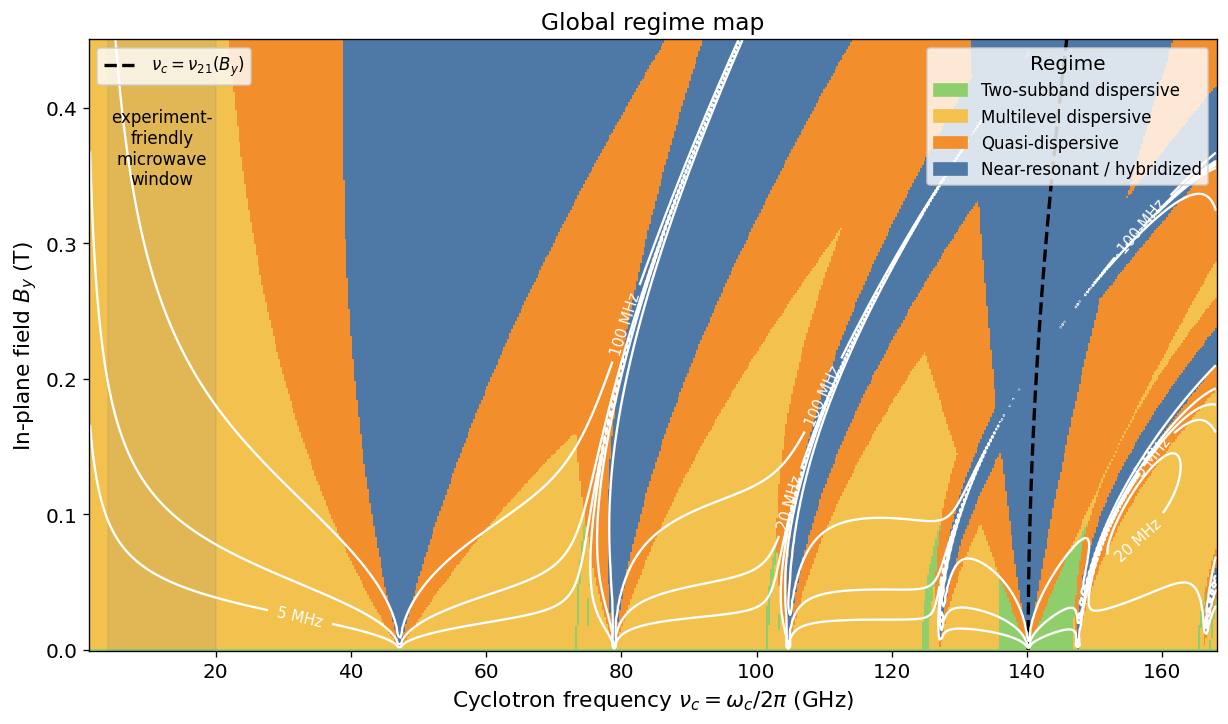

Saved: C:\notebooks\new_EonHe\ehe_theory_figures\global_regime_map.png


In [19]:
ETA_DISPERSIVE = 0.10
ETA_HYBRID = 0.25
RELERR_TWO_SUB = 0.15

def global_regime_map(cfg, By_values, Bz_values, eta_cut1=ETA_DISPERSIVE, eta_cut2=ETA_HYBRID, relerr_cut=RELERR_TWO_SUB):
    class_map = np.zeros((len(By_values), len(Bz_values)), dtype=int)
    split_map = np.zeros_like(class_map, dtype=float)
    w21_map = np.zeros(len(By_values))

    for i, By in enumerate(By_values):
        sol = solve_vertical(By, cfg)
        E = sol["energies_J"]
        Z = sol["zmat_m"]
        w21_map[i] = frequency_GHz((E[1] - E[0]) / hbar)

        for j, Bz in enumerate(Bz_values):
            d1 = multilevel_shift(E, Z, Bz, By, 0, n_use=cfg.n_states)
            d2 = multilevel_shift(E, Z, Bz, By, 1, n_use=cfg.n_states)
            two = two_subband_shifts(E, Z, Bz, By)

            split_multi = shift_MHz(abs(d2 - d1))
            split_two = shift_MHz(abs(two["delta_excited"] - two["delta_ground"]))
            err_two = abs(split_multi - split_two) / max(split_multi, 1e-12)
            eta_here = eta_max(E, Z, Bz, By, n_use=cfg.n_states)

            split_map[i, j] = split_multi

            if eta_here >= eta_cut2:
                class_map[i, j] = 3
            elif eta_here >= eta_cut1:
                class_map[i, j] = 2
            elif err_two >= relerr_cut:
                class_map[i, j] = 1
            else:
                class_map[i, j] = 0

    return class_map, split_map, w21_map

By_global = np.linspace(0.0, 0.45, 451)
Bz_global = np.linspace(0.05, 6.0, 596)
nu_global = frequency_GHz(cyclotron_frequency(Bz_global))

class_map, split_global, w21_global = global_regime_map(cfg, By_global, Bz_global)

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

regime_cmap = ListedColormap([
    "#8ecf6b",  # two-subband dispersive
    "#f2c14e",  # multilevel dispersive
    "#f28e2b",  # quasi-dispersive
    "#4e79a7",  # hybridized
])
regime_norm = BoundaryNorm(np.arange(-0.5, 4.5, 1), regime_cmap.N)

fig, ax = plt.subplots(figsize=(10.4, 6.2))
mesh = ax.pcolormesh(nu_global, By_global, class_map, cmap=regime_cmap, norm=regime_norm, shading="nearest")

# Experimental 4-20 GHz window
ax.axvspan(4.0, 20.0, color="gray", alpha=0.14)

# Resonance of the lowest vertical transition
ax.plot(w21_global, By_global, "k--", lw=2.0, label=r"$\nu_c=\nu_{21}(B_y)$")

# Splitting contours
cont = ax.contour(nu_global, By_global, split_global, levels=[5, 20, 100], colors="white", linewidths=1.4)
ax.clabel(cont, fmt=lambda x: f"{int(x)} MHz", fontsize=9, inline=True)

ax.set_xlabel(r"Cyclotron frequency $\nu_c=\omega_c/2\pi$ (GHz)")
ax.set_ylabel(r"In-plane field $B_y$ (T)")
ax.set_title("Global regime map")

patches = [
    Patch(color="#8ecf6b", label="Two-subband dispersive"),
    Patch(color="#f2c14e", label="Multilevel dispersive"),
    Patch(color="#f28e2b", label="Quasi-dispersive"),
    Patch(color="#4e79a7", label="Near-resonant / hybridized"),
]
leg1 = ax.legend(handles=patches, title="Regime", loc="upper right", frameon=True)
ax.add_artist(leg1)
ax.legend(loc="upper left", frameon=True)

ax.text(12, 0.37, "experiment-\nfriendly\nmicrowave\nwindow", ha="center", va="center", fontsize=10)
#ax.text(31.5, 0.36, "multilevel\ndispersive", ha="center", va="center", fontsize=11)
#ax.text(66, 0.26, "quasi-\ndispersive", ha="center", va="center", fontsize=11, rotation=24)
#ax.text(138, 0.17, "hybridized", ha="center", va="center", fontsize=11, rotation=90)

plt.tight_layout()

global_map_path = figure_dir / "global_regime_map.png"
plt.savefig(global_map_path, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved: {global_map_path}")